# Juan Carlos Monterrosa Jimenez - grupo CH9
# Taller análisis descriptivo de variables cualitativas

Se va a trabajar con un dataset que contiene información sobre incidentes de tránsito en Medellín con víctimas.

Cárguelo y verifique que se haya cargado correctamente.

In [15]:
from google.colab import files

uploaded = files.upload()


Saving Accidentes de tránsito en Medellín.csv to Accidentes de tránsito en Medellín.csv


In [17]:
import os

os.listdir()

['.config', 'Accidentes de tránsito en Medellín.csv', 'sample_data']

In [18]:
df = pd.read_csv("Accidentes de tránsito en Medellín.csv")

In [24]:
import pandas as pd

df.head()

,Fecha_incidente,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Barrio,Dia_semana,Mes,Año
0,2014-01-01,Heridos,Otro,M,Motociclista,10 - 19,04 - Aranjuez,Manrique Central No. 1,Miércoles,Enero,2014
1,2014-01-01,Heridos,Atropello,M,Motociclista,20 - 29,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
2,2014-01-01,Heridos,Atropello,F,Peatón,10 - 19,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
3,2014-01-01,Heridos,Atropello,M,Motociclista,10 - 19,16 - Belén,Las Mercedes,Miércoles,Enero,2014
4,2014-01-01,Heridos,Atropello,M,Peatón,30 - 39,16 - Belén,Las Mercedes,Miércoles,Enero,2014


In [25]:
# dimensiones del dataset
print("Filas y columnas:", df.shape)

Filas y columnas: (235843, 11)


In [27]:
#nombre de las columnas
print(df.columns)

Index(['Fecha_incidente', 'Gravedad_victima', 'Clase_incidente', 'Sexo',
       'Condicion', 'Grupo_edad', 'Comuna', 'Barrio', 'Dia_semana', 'Mes',
       'Año'],
      dtype='object')


In [29]:
# vericacion tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235843 entries, 0 to 235842
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Fecha_incidente   235843 non-null  object
 1   Gravedad_victima  235843 non-null  object
 2   Clase_incidente   235843 non-null  object
 3   Sexo              233366 non-null  object
 4   Condicion         235843 non-null  object
 5   Grupo_edad        233309 non-null  object
 6   Comuna            214117 non-null  object
 7   Barrio            213961 non-null  object
 8   Dia_semana        235843 non-null  object
 9   Mes               235843 non-null  object
 10  Año               235843 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 19.8+ MB


La variable "Fecha_incidente" debe convertirse a dato de tiempo.

Excluya los datos del año 2021.

In [32]:
# Convertir Fecha_incidente a tipo fecha
df["Fecha_incidente"] = pd.to_datetime(df["Fecha_incidente"])

# Excluir los registros del año 2021
df = df[df["Fecha_incidente"].dt.year != 2021]

# Verificar el resultado
print(df["Fecha_incidente"].dtype)
print(df["Fecha_incidente"].min())
print(df["Fecha_incidente"].max())

datetime64[ns]
2014-01-01 00:00:00
2020-12-31 00:00:00


In [33]:
# Tipo de dato
print(df["Fecha_incidente"].dtype)

# Años presentes después del filtro
print(sorted(df["Fecha_incidente"].dt.year.unique()))

datetime64[ns]
[np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]


De acuerdo a lo visto en clase, indique qué tipo de variable es cada una de las que están en el DataFrame.

Convierta a "category" las variables categóricas, cuidando que las variables nominales y ordinales queden correctamente convertidas.

#respuesta
Fecha_incidente: Variable temporal (fecha).

Gravedad_victima: Variable cualitativa categórica ordinal (existe un orden en la gravedad).

Clase_incidente: Variable cualitativa categórica nominal.

Sexo: Variable cualitativa categórica nominal.

Condicion: Variable cualitativa categórica nominal.

Grupo_edad: Variable cualitativa categórica ordinal (rangos de edad ordenados).

Comuna: Variable cualitativa categórica nominal.

Barrio: Variable cualitativa categórica nominal.

Dia_semana: Variable cualitativa categórica ordinal (tiene una secuencia temporal).

Mes: Variable cualitativa categórica ordinal (orden natural de enero a diciembre).

Año: Variable cuantitativa discreta.

In [34]:
# Fecha
df["Fecha_incidente"] = pd.to_datetime(df["Fecha_incidente"])

# Variables nominales
nominales = [
  "Clase_incidente",
  "Sexo",
  "Condicion",
  "Comuna",
  "Barrio"
]

for col in nominales:
  df[col] = df[col].astype("category")

In [35]:
df.dtypes

,0
Fecha_incidente,datetime64[ns]
Gravedad_victima,object
Clase_incidente,category
Sexo,category
Condicion,category
Grupo_edad,object
Comuna,category
Barrio,category
Dia_semana,object
Mes,object


Identifique qué variable(s) tienen alta cardinalidad. Excluya esta(s) de los análisis posteriores.

In [38]:
cardinalidad = pd.DataFrame({
"Variable": df.columns,
"Cardinalidad": [df[col].nunique() for col in df.columns]
}).sort_values("Cardinalidad", ascending=False)

cardinalidad

,Variable,Cardinalidad
0,Fecha_incidente,2557
7,Barrio,418
6,Comuna,21
9,Mes,12
5,Grupo_edad,9
8,Dia_semana,7
4,Condicion,7
10,Año,7
2,Clase_incidente,6
1,Gravedad_victima,2


In [39]:
# Cardinalidad de cada variable

cardinalidad = df.nunique().sort_values(ascending=False)

print(cardinalidad)

Fecha_incidente     2557
Barrio               418
Comuna                21
Mes                   12
Grupo_edad             9
Dia_semana             7
Condicion              7
Año                    7
Clase_incidente        6
Gravedad_victima       2
Sexo                   2
dtype: int64


#Respuesta
Las variables con mayor cardinalidad fueron Barrio y Fecha_incidente, debido a que presentan un gran número de valores distintos.

Haga las tablas de frecuencias porcentuales de todas las variables categóricas.

Para cada variable, indique cuál es la categoría más frecuente y cuál la menos frecuente.

Identifique qué variables presentan categorías atípicas. Indique los nombres de las categorías atípicas.

In [40]:
# Variables categóricas
cat_cols = df.select_dtypes(include=["category"]).columns

for col in cat_cols:
  print(f"\n{'='*50}")
  print(f"Variable: {col}")
  print(df[col].value_counts(normalize=True, dropna=False)*100)


Variable: Clase_incidente
Clase_incidente
Choque            43.970558
Otro              17.234583
Atropello         16.960900
Caida Ocupante    15.231930
Volcamiento        6.591754
Incendio           0.010275
Name: proportion, dtype: float64

Variable: Sexo
Sexo
M      68.828579
F      30.408283
NaN     0.763138
Name: proportion, dtype: float64

Variable: Condicion
Condicion
Motociclista                  60.093127
Peatón                        13.921893
Acompañante de Motocicleta    13.498291
Pasajero                       5.835155
Conductor                      2.659306
Ciclista                       2.256254
Acompañante de motocicleta     1.735975
Name: proportion, dtype: float64

Variable: Comuna
Comuna
10 - La Candelaria                                 15.706907
05 - Castilla                                       9.803564
NaN                                                 8.845205
11 - Laureles Estadio                               8.513609
07 - Robledo                          

In [50]:
#Categoría más frecuente y menos frecuente
for col in cat_cols:
   conteos = df[col].value_counts()

mas_frecuente = conteos.idxmax()
menos_frecuente = conteos.idxmin()

print(f"\nVariable: {col}")
print(f"Más frecuente: {mas_frecuente} ({conteos.max()} casos)")
print(f"Menos frecuente: {menos_frecuente} ({conteos.min()} casos)")


Variable: Barrio
Más frecuente: Caribe (3651 casos)
Menos frecuente: 12Sin Inf2 (1 casos)


In [52]:
#Identificación de categorías atípicas
for col in cat_cols:
  porcentaje = df[col].value_counts(normalize=True) * 100

  atipicas = porcentaje[porcentaje < 1]

  if len(atipicas) > 0:
    print(f"\nVariable: {col}")
    print("Categorías atípicas:")
    print(atipicas)


Variable: Clase_incidente
Categorías atípicas:
Clase_incidente
Incendio    0.010275
Name: proportion, dtype: float64

Variable: Comuna
Categorías atípicas:
Comuna
70 - Corregimiento de Altavista                    0.339179
90 - Corregimiento de Santa Elena                  0.283333
50 - Corregimiento de San Sebastián de Palmitas    0.010759
Name: proportion, dtype: float64

Variable: Barrio
Categorías atípicas:
Barrio
San Diego                   0.939826
Guayabal                    0.882401
Jesús Nazareno              0.879325
Cristo Rey                  0.878812
Belén                       0.868558
                              ...   
Travesías                   0.000513
1Sin InfSin Inf4            0.000513
Universidad De Antioquia    0.000513
Veinte De Julio             0.000513
Versalles No.2              0.000513
Name: proportion, Length: 400, dtype: float64


#Respuesta
Se calcularon las tablas de frecuencias porcentuales para las variables categóricas analizadas.

Clase_incidente: la categoría más frecuente fue Choque (43,97%) y la menos frecuente fue Incendio (0,01%).

Sexo: la categoría más frecuente fue M (68,83%) y la menos frecuente fue F (30,41%). Adicionalmente se observó un 0,76% de valores faltantes.

Condicion: la categoría más frecuente fue Motociclista (60,09%) y la menos frecuente fue Acompañante de motocicleta (1,74%).

Comuna: la categoría más frecuente fue 10 - La Candelaria (15,71%) y la menos frecuente fue 50 - Corregimiento de San Sebastián de Palmitas (0,01%).

Considerando como categorías atípicas aquellas con una frecuencia relativa inferior al 1%, se identificaron las siguientes:

En Clase_incidente, la categoría Incendio (0,01%).
En Comuna, las categorías 70 - Corregimiento de Altavista (0,34%), 90 - Corregimiento de Santa Elena (0,28%) y 50 - Corregimiento de San Sebastián de Palmitas (0,01%).

No se encontraron categorías atípicas en las variables Sexo y Condicion.

*Se detectó una posible inconsistencia en la variable Condicion, donde aparecen las categorías "Acompañante de Motocicleta" y "Acompañante de motocicleta"*

Para las variables nominales, haga un gráfico de barras horizontales de la tabla de frecuencia relativa, ordenados de forma descendente.

Para las variables ordinales, haga un gráfico de barras verticales de la tabla de frecuencia relativa, ordenados de acuerdo al orden de las categorías.

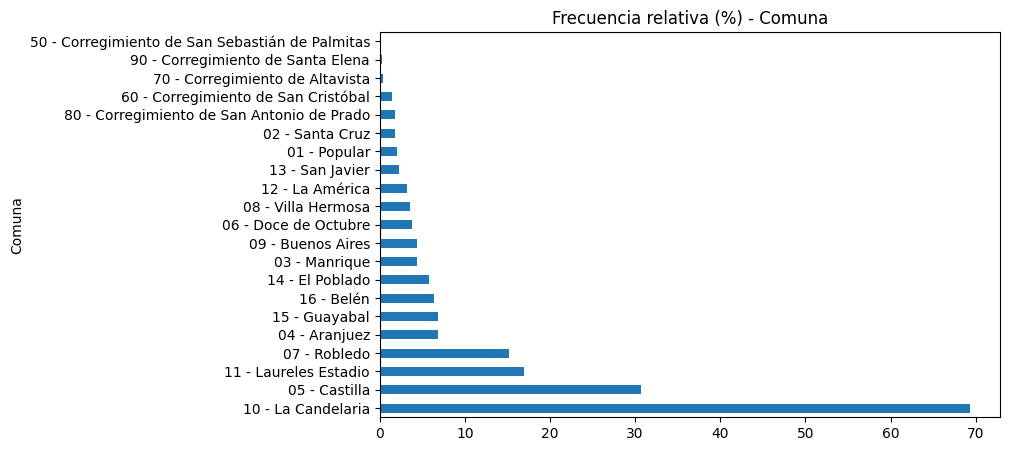

In [59]:
#variables nominales
nominales = [
"Clase_incidente",
"Sexo",
"Condicion",
"Comuna"
]

for col in nominales:

  (df[col]
    .value_counts(normalize=True)
    .mul(100)
    .plot(
      kind="barh",
      title=f"Frecuencia relativa (%) - {col}",
      figsize=(8,5)
  ))

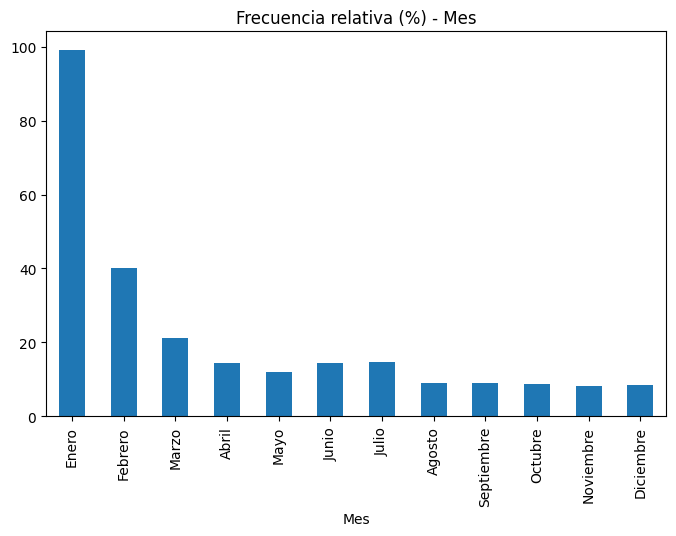

In [60]:
#variables ordinales
ordinales = [
"Gravedad_victima",
"Grupo_edad",
"Dia_semana",
"Mes"
]

for col in ordinales:

  (df[col]
    .value_counts(normalize=True, sort=False)
    .mul(100)
    .plot(
      kind="bar",
      title=f"Frecuencia relativa (%) - {col}",
      figsize=(8,5)
  ))

Para las variables ordinales, haga un gráfico de barras vertical de la tabla de frecuencia acumulada, ordenada de acuerdo al orden de las categorías.

Para las variables ordinales, calcule la mediana, y los quartiles 1, 2 y 3.

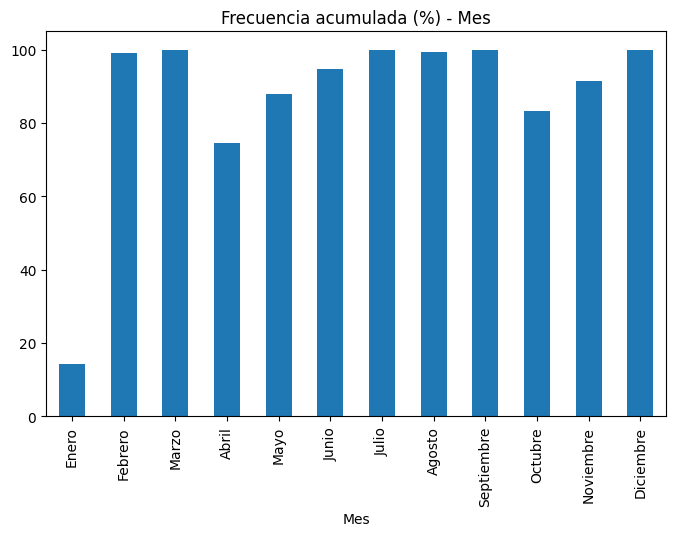

In [105]:
ordinales = [
  "Gravedad_victima",
  "Grupo_edad",
  "Dia_semana",
  "Mes"
]

for col in ordinales:



  frecuencia_acum = (
    df[col]
    .value_counts(normalize=True, sort=False)
    .cumsum()
    .mul(100)
  )

  frecuencia_acum.plot(
    kind="bar",
    title=f"Frecuencia acumulada (%) - {col}",
    figsize=(8, 5)
    )

In [104]:
# Gravedad_victima
df["Gravedad_victima"] = pd.Categorical(
df["Gravedad_victima"],
  categories=["Ilesos", "Heridos", "Muertos"],
  ordered=True
  )

# Día semana
df["Dia_semana"] = pd.Categorical(
  df["Dia_semana"],
  categories=[
  "Lunes", "Martes", "Miércoles",
  "Jueves", "Viernes", "Sábado", "Domingo"
  ],
  ordered=True
)

# Mes
df["Mes"] = pd.Categorical(
df["Mes"],
categories=[
"Enero", "Febrero", "Marzo", "Abril",
"Mayo", "Junio", "Julio", "Agosto",
"Septiembre", "Octubre", "Noviembre", "Diciembre"
],
ordered=True
)

In [71]:
df[ordinales].dtypes

,0
Gravedad_victima,object
Grupo_edad,object
Dia_semana,object
Mes,object


In [73]:
for col in ordinales:

  print(col, df[col].dtype)

Gravedad_victima object
Grupo_edad object
Dia_semana object
Mes object


In [74]:
for col in ordinales:

  df[col] = df[col].astype("category")

In [75]:
df[ordinales].head()

df[ordinales].dtypes

,0
Gravedad_victima,category
Grupo_edad,category
Dia_semana,category
Mes,category


In [77]:
for col in ordinales:

  codigos = df[col].cat.codes

  q1 = codigos.quantile(0.25)
  q2 = codigos.quantile(0.50)
  q3 = codigos.quantile(0.75)

  print(f"\nVariable: {col}")
  print(f"Q1 = {q1}")
  print(f"Q2 (Mediana) = {q2}")
  print(f"Q3 = {q3}")


Variable: Gravedad_victima
Q1 = 0.0
Q2 (Mediana) = 0.0
Q3 = 0.0

Variable: Grupo_edad
Q1 = 2.0
Q2 (Mediana) = 2.0
Q3 = 4.0

Variable: Dia_semana
Q1 = 1.0
Q2 (Mediana) = 3.0
Q3 = 5.0

Variable: Mes
Q1 = 3.0
Q2 (Mediana) = 6.0
Q3 = 9.0
